In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers = ['AAPL']
prices = yf.download(tickers, start = '2021-01-01', end = '2025-02-23')['Close']

[*********************100%***********************]  1 of 1 completed


In [3]:
daily_rets = prices.pct_change().dropna()
daily_rets

Ticker,AAPL
Date,
2021-01-05,0.012364
2021-01-06,-0.033662
2021-01-07,0.034123
2021-01-08,0.008631
2021-01-11,-0.023249
...,...
2025-02-14,0.012711
2025-02-18,-0.000531
2025-02-19,0.001636


In [4]:
mean = daily_rets.mean()
vol = daily_rets.std()
mean, vol

(Ticker
 AAPL    0.00078
 dtype: float64,
 Ticker
 AAPL    0.01679
 dtype: float64)

In [5]:
# Estrategia
capital = 5000
dca = 100
semanas = capital/dca
d_semana = 5
total_dias = d_semana*semanas
n = 10000

In [6]:
# Simulación
dias_simulacion = int(total_dias)
retornos_sim = np.random.normal(mean, vol, (dias_simulacion, n))

trayectorias = np.cumprod(1 + retornos_sim, axis=0)
trayectorias = np.vstack([np.ones(n), trayectorias])

In [7]:
# Estrategia 1
valor_final_unica = capital * trayectorias[-1]
evolucion_unica = np.mean(trayectorias * capital, axis=1)

# Estrategia 2
portafolio_dca_sim = np.zeros((dias_simulacion + 1, n))

for i in range(int(semanas)):
    dia_compra = i * d_semana
    # Cada aportación de $100 crece según el rendimiento del activo desde su día de compra
    # Rendimiento = Precio_Actual / Precio_Día_Compra
    rendimiento_desde_entrar = trayectorias[dia_compra:] / trayectorias[dia_compra]
    portafolio_dca_sim[dia_compra:] += dca * rendimiento_desde_entrar

# Calculamos el efectivo que aún no se ha invertido para sumarlo al valor del patrimonio
# Esto asegura que la gráfica de DCA también empiece en $5,000
efectivo_restante = np.maximum(0, capital - (np.arange(dias_simulacion + 1) // d_semana * dca + dca))
valor_total_dca_sim = portafolio_dca_sim + efectivo_restante[:, np.newaxis]


valor_final_dca = valor_total_dca_sim[-1]
evolucion_dca_promedio = np.mean(valor_total_dca_sim, axis=1)


In [8]:
# --- 5. Métricas y Tabla de Resultados ---
stats = pd.DataFrame({
    'Inversión Única': [valor_final_unica.mean(), valor_final_unica.std(), (valor_final_unica < capital).mean()],
    'DCA': [valor_final_dca.mean(), valor_final_dca.std(), (valor_final_dca < capital).mean()]
}, index=['Valor Final Promedio', 'Desviación Estándar', 'Prob. de Pérdida'])

print("--- Comparativa de Estrategias ---")
print(stats)


--- Comparativa de Estrategias ---
                      Inversión Única          DCA
Valor Final Promedio      6089.959907  5536.947604
Desviación Estándar       1668.039283   897.615653
Prob. de Pérdida             0.278300     0.292700


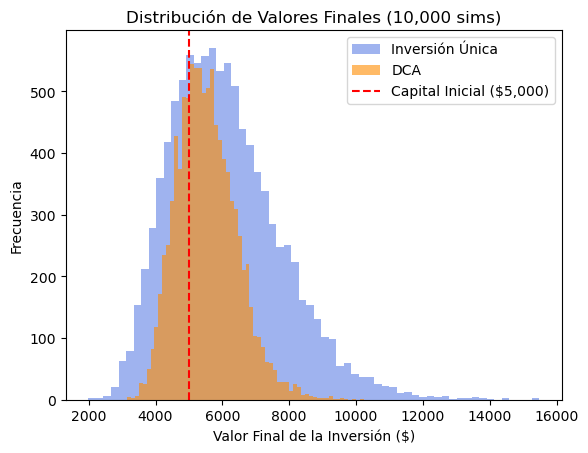

In [12]:
# Histogramas
plt.subplot(1, 1, 1)
plt.hist(valor_final_unica, bins=60, alpha=0.5, label='Inversión Única', color='royalblue')
plt.hist(valor_final_dca, bins=60, alpha=0.6, label='DCA', color='darkorange')
plt.axvline(capital, color='red', linestyle='--', label='Capital Inicial ($5,000)')
plt.title('Distribución de Valores Finales (10,000 sims)')
plt.xlabel('Valor Final de la Inversión ($)')
plt.ylabel('Frecuencia')
plt.legend()

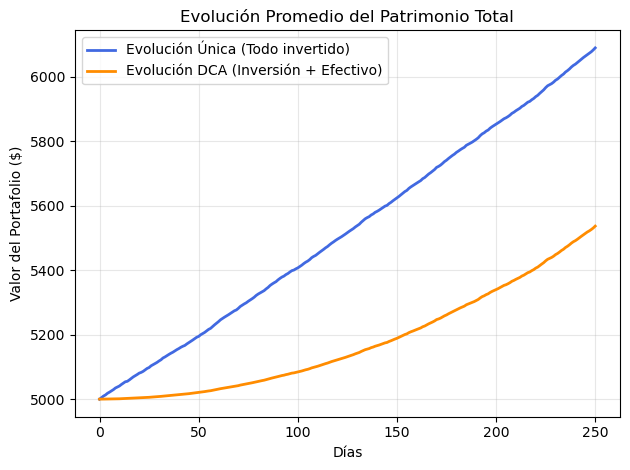

In [13]:
# Comparativa de evolución
plt.subplot(1, 1,1)
plt.plot(evolucion_unica, label='Evolución Única (Todo invertido)', color='royalblue', linewidth=2)
plt.plot(evolucion_dca_promedio, label='Evolución DCA (Inversión + Efectivo)', color='darkorange', linewidth=2)
plt.title('Evolución Promedio del Patrimonio Total')
plt.xlabel('Días')
plt.ylabel('Valor del Portafolio ($)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Desde mi punto de vista la inversión períodica solo es preferible cuando necesitas liquidez ya que en ningún punto genera mas rendimiento que la inversión de 1 solo momento